# Clustering Analysis

clustering → hyperparameter tuning → Analysis: **which clustering method is correct?**

1000 sentences OK

- Clustering Method
    1. kmeans
    2. greedy
    3. graph-based
    4. dbscan
    5. hierachical clustering
    6. predict to the next sentences

Analysis:
  - what is the right cluster?
  - what makes kmeans/dbscan/greedy correct?

## Dataset & Model

In [1]:
# use wikipedia dataset
import json

filename = "/content/love_2000_sentences.json"
with open(filename, "r", encoding="utf-8") as f:
  sentences = json.load(f)

print(sentences)

['she d always loved how the dress made her feel sexy , but at the same time was very respectable .', 'she loved her newest cousin very much and planned to be the best godmother she could for him .', 'he loved them too much to be denied .', 'it was nt until she fell in love for the first time in her life that she threw everything away .', 'sadly , she could nt say that her first love was davis , mason s father .', 'he loved sitting between her brothers on the couch and watching tv .', 'aw , you love your godmother , do nt you noah ?', 'i could never , ever love another man like i do him', 'especially if the last woman he cared about loved someone else', 'nothing would make me happier than if you were to fall in love with pesh', 'i know i would love to work alongside someone who had your passion', 'thank god he loves his baths ,  aidan muttered beside pesh .', 'i love aidan , but he s not necessarily a gentleman .', 'and with a wink , he walked off to join emma , leaving megan to wonder

In [2]:
print(len(sentences))

2000


In [3]:
import torch
from transformers import BertTokenizer, BertModel, BertForMaskedLM

model_name = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForMaskedLM.from_pretrained(model_name, output_hidden_states=True) # predict next words
model.eval()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

## Get Embeddings (final & intermediate) through BERT

In [4]:
## define the function that extracts Features

def get_features(sentence, model, tokenizer, layer_indices=[-1, -4]):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True, max_length=128)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)  # Ensure hidden states are returned

    hidden_states = outputs.hidden_states  # Extract all hidden states

    # Extract final layer embedding (CLS token representation)
    final_layer_emb = hidden_states[layer_indices[0]][:, 0, :].squeeze(0).cpu().numpy()

    # Extract intermediate layer embedding (e.g., -4th layer)
    intermediate_layer_emb = hidden_states[layer_indices[1]][:, 0, :].squeeze(0).cpu().numpy()

    return final_layer_emb, intermediate_layer_emb

In [5]:
import numpy as np

batch_size = 32
num_batches = len(sentences) // batch_size + (len(sentences) % batch_size != 0)

final_embeddings = []
intermediate_embeddings = []

for i in range(num_batches):
    batch = sentences[i * batch_size: (i + 1) * batch_size]

    # Get embeddings from model
    batch_final_emb, batch_inter_emb = zip(*[get_features(sent, model, tokenizer) for sent in batch])

    final_embeddings.extend(batch_final_emb)
    intermediate_embeddings.extend(batch_inter_emb)

final_embeddings = np.array(final_embeddings)
intermediate_embeddings = np.array(intermediate_embeddings)

print("Final embedding shape:", final_embeddings.shape)
print("Intermediate embedding shape:", intermediate_embeddings.shape)

Final embedding shape: (2000, 768)
Intermediate embedding shape: (2000, 768)


## Clustering
1. Greedy
2. graph-based
3. K-means
4. dbscan

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

final_cos_similar = cosine_similarity(final_embeddings)
inter_cos_similar = cosine_similarity(intermediate_embeddings)

In [7]:
print("Cosine Similarity of Final Embeddings")
print(np.round(final_cos_similar[:5, :5], 2))
print("Cosine Similarity of Intermediate Embeddings")
print(np.round(inter_cos_similar[:5, :5], 2))

Cosine Similarity of Final Embeddings
[[1.   0.89 0.85 0.83 0.85]
 [0.89 1.   0.89 0.86 0.87]
 [0.85 0.89 1.   0.89 0.84]
 [0.83 0.86 0.89 1.   0.88]
 [0.85 0.87 0.84 0.88 1.  ]]
Cosine Similarity of Intermediate Embeddings
[[1.   0.92 0.89 0.86 0.92]
 [0.92 1.   0.91 0.87 0.93]
 [0.89 0.91 1.   0.89 0.88]
 [0.86 0.87 0.89 1.   0.9 ]
 [0.92 0.93 0.88 0.9  1.  ]]


In [8]:
thres = 0.8
n = len(sentences)

In [9]:
!pip install kneed

In [10]:
from scipy.stats import linregress
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import networkx as nx
import matplotlib.pyplot as plt
from kneed import KneeLocator

In [11]:
# 1. Simple Greedy Approcah
def grouping(cos_similar, n, thres):
  groups = []
  visited = set()

  for i in range(n):
    if i in visited:
      continue

    group = [i]
    visited.add(i)

    for j in range(n):
      if j not in visited and cos_similar[i][j] >= thres:
        group.append(j)
        visited.add(j)

    groups.append(group)

  return groups


# 2. graph-based grouping (connected componenets) - clustering
def graph_based_grouping(cos_similar, n, thres):
  graph = nx.Graph()

  graph.add_nodes_from(range(n))

  for i in range(n):
    for j in range(i+1, n):
      if cos_similar[i][j] >= thres:
        graph.add_edge(i, j)

  groups = [list(component) for component in nx.connected_components(graph)]

  return groups


# 3. Clustering using DBSCAN
def clustering_grouping(embedding, thres):
  eps = 1 - thres
  clustering = DBSCAN(eps=eps, min_samples=2, metric="cosine").fit(embedding)
  labels = clustering.labels_

  # print("The number of clusters:", len(set(labels))-(1 if -1 in labels else 0))

  groups = {}
  for idx, label in enumerate(labels):
    if label not in groups:
      groups[label] = []
    groups[label].append(idx)
  return list(groups.values())


# 4. Kmeans - elbow analysis
def kmeans_elbow(embeddings, k_range):
    inertias = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(embeddings)
        inertias.append(kmeans.inertia_)
    return inertias # within-cluster sum of squres

def plot_elbow_with_knee(k_range, inertias, title="KMeans Elbow Plot"):
    k_vals = list(k_range)

    kl = KneeLocator(k_vals, inertias, curve="convex", direction="decreasing")
    optimal_k = kl.elbow

    plt.figure(figsize=(8, 5))
    plt.plot(k_vals, inertias, marker='o', label="Inertia")
    if optimal_k:
        plt.axvline(optimal_k, color='red', linestyle='--', label=f"Optimal k = {optimal_k}")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return optimal_k

### 1. Greedy clustering

In [12]:
# greedy
final_greedy = grouping(final_cos_similar, n, thres)
inter_greedy = grouping(inter_cos_similar, n, thres)

In [13]:
print(f"Greedy Clustering (Final Layer): {len(final_greedy)} clusters")
print(f"Greedy Clustering (Intermediate Layer): {len(inter_greedy)} clusters")

Greedy Clustering (Final Layer): 45 clusters
Greedy Clustering (Intermediate Layer): 37 clusters


In [14]:
def get_labels_from_groups(groups, n_samples):
    labels = [-1] * n_samples
    for cluster_id, group in enumerate(groups):
        for idx in group:
            labels[idx] = cluster_id
    return labels

In [15]:
from sklearn.metrics import silhouette_score

# Final Greedy
labels = get_labels_from_groups(final_greedy, n_samples=len(final_embeddings))
score = silhouette_score(final_embeddings, labels, metric='cosine')
print(f"Final Greedy Silhouette: {score:.3f}")

# Intermediate Greedy
labels = get_labels_from_groups(inter_greedy, n_samples=len(intermediate_embeddings))
score = silhouette_score(intermediate_embeddings, labels, metric='cosine')
print(f"Intermediate Greedy Silhouette: {score:.3f}")

Final Greedy Silhouette: 0.092
Intermediate Greedy Silhouette: 0.043


### 1-2. GREEDY CLUSTER ANALYSIS
- Final Layer Greedy Clustering
  - Number of clusters: 136 -> 45
  - Silhouette Score: −0.041 -> 0.092
- Intermediate Layer Greedy Clustering
  - Number of clusters: 40 -> 37
  - Silhouette Score: −0.004 -> 0.043

### 2. Graph-based Clustering

In [16]:
# graph
final_graph = graph_based_grouping(final_cos_similar, n, thres)
inter_graph = graph_based_grouping(inter_cos_similar, n, thres)

In [17]:
print(f"Graph-based Clustering (Final Layer): {len(final_graph)} clusters")
print(f"Graph-based Clustering (Intermediate Layer): {len(inter_graph)} clusters")

Graph-based Clustering (Final Layer): 2 clusters
Graph-based Clustering (Intermediate Layer): 2 clusters


In [18]:
# Final Graph
labels = get_labels_from_groups(final_graph, n_samples=len(final_embeddings))
score = silhouette_score(final_embeddings, labels, metric='cosine')
print(f"Final Graph Silhouette: {score:.3f}")

# Intermediate Graph
labels = get_labels_from_groups(inter_graph, n_samples=len(intermediate_embeddings))
score = silhouette_score(intermediate_embeddings, labels, metric='cosine')
print(f"Intermediate Graph Silhouette: {score:.3f}")

Final Graph Silhouette: 0.604
Intermediate Graph Silhouette: 0.427


### 2-2. GRAPH-BASED CLUSTER ANALYSIS
- Final Layer Graph-based Clustering
  - Silhouette Score: 0.096 -> 0.604
- Intermediate Layer Graph-based Clustering
  - Silhouette Score: 0.411 -> 0.427

### 3. DBSCAN Clustering
- dbcsan hyperparameter tuning

In [19]:
def tune_dbscan(embeddings, threshold_list):
    results = []
    for thres in threshold_list:
        eps = 1 - thres
        dbscan = DBSCAN(eps=eps, min_samples=2, metric="cosine").fit(embeddings)
        labels = dbscan.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        results.append((thres, n_clusters, n_noise))
    return results

In [20]:
thresholds = [0.7, 0.75, 0.8, 0.85, 0.9]

final_dbscan_results = tune_dbscan(final_embeddings, thresholds)
inter_dbscan_results = tune_dbscan(intermediate_embeddings, thresholds)

print("FINAL EMBEDDINGS")
for thres, n_clusters, n_noise in final_dbscan_results:
    print(f"Threshold: {thres}, #Clusters: {n_clusters}, Noise Points: {n_noise}")

print("INTERMEDIATE EMBEDDINGS")
for thres, n_clusters, n_noise in inter_dbscan_results:
    print(f"Threshold: {thres}, #Clusters: {n_clusters}, Noise Points: {n_noise}")

FINAL EMBEDDINGS
Threshold: 0.7, #Clusters: 1, Noise Points: 0
Threshold: 0.75, #Clusters: 1, Noise Points: 0
Threshold: 0.8, #Clusters: 1, Noise Points: 1
Threshold: 0.85, #Clusters: 1, Noise Points: 15
Threshold: 0.9, #Clusters: 6, Noise Points: 239
INTERMEDIATE EMBEDDINGS
Threshold: 0.7, #Clusters: 1, Noise Points: 0
Threshold: 0.75, #Clusters: 1, Noise Points: 0
Threshold: 0.8, #Clusters: 1, Noise Points: 1
Threshold: 0.85, #Clusters: 1, Noise Points: 8
Threshold: 0.9, #Clusters: 8, Noise Points: 112


In [21]:
from sklearn.metrics import silhouette_score

def evaluate_clustering(embeddings, labels):
    if len(set(labels)) > 1 and -1 not in set(labels):  # avoid noise only or one cluster
        score = silhouette_score(embeddings, labels, metric="cosine")
    else:
        score = -1
    return score


In [22]:
print("FINAL EMBEDDINGS")
for thres in thresholds:
    eps = 1 - thres
    labels = DBSCAN(eps=eps, min_samples=2, metric="cosine").fit_predict(final_embeddings)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"Threshold: {thres}, #Clusters: {n_clusters}, Noise: {n_noise}")

    score = evaluate_clustering(final_embeddings, labels)
    print(f"DBSCAN threshold {thres}: Silhouette = {score:.3f}")

print("INTERMEDIATE EMBEDDINGS")
for thres in thresholds:
    eps = 1 - thres
    labels = DBSCAN(eps=eps, min_samples=2, metric="cosine").fit_predict(intermediate_embeddings)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"Threshold: {thres}, #Clusters: {n_clusters}, Noise: {n_noise}")

    score = evaluate_clustering(intermediate_embeddings, labels)
    print(f"DBSCAN threshold {thres}: Silhouette = {score:.3f}")

FINAL EMBEDDINGS
Threshold: 0.7, #Clusters: 1, Noise: 0
DBSCAN threshold 0.7: Silhouette = -1.000
Threshold: 0.75, #Clusters: 1, Noise: 0
DBSCAN threshold 0.75: Silhouette = -1.000
Threshold: 0.8, #Clusters: 1, Noise: 1
DBSCAN threshold 0.8: Silhouette = -1.000
Threshold: 0.85, #Clusters: 1, Noise: 15
DBSCAN threshold 0.85: Silhouette = -1.000
Threshold: 0.9, #Clusters: 6, Noise: 239
DBSCAN threshold 0.9: Silhouette = -1.000
INTERMEDIATE EMBEDDINGS
Threshold: 0.7, #Clusters: 1, Noise: 0
DBSCAN threshold 0.7: Silhouette = -1.000
Threshold: 0.75, #Clusters: 1, Noise: 0
DBSCAN threshold 0.75: Silhouette = -1.000
Threshold: 0.8, #Clusters: 1, Noise: 1
DBSCAN threshold 0.8: Silhouette = -1.000
Threshold: 0.85, #Clusters: 1, Noise: 8
DBSCAN threshold 0.85: Silhouette = -1.000
Threshold: 0.9, #Clusters: 8, Noise: 112
DBSCAN threshold 0.9: Silhouette = -1.000


### 3-2. DBSCAN TUNING ANALYSIS
Based on the results shown, DBSCAN appears to have failed to produce meaningful clusters across all tested thresholds. The evidence is as follows:
- Silhouette Score = -1.000 for All Cases

### 4. K-means Clustering

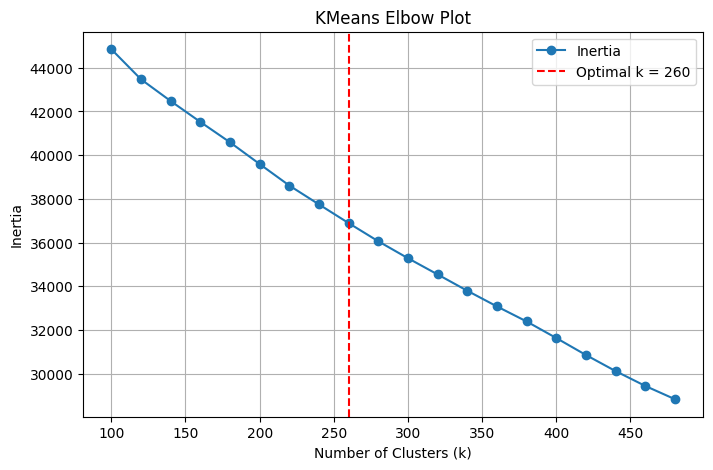

KMeans final embeddings: (k=260


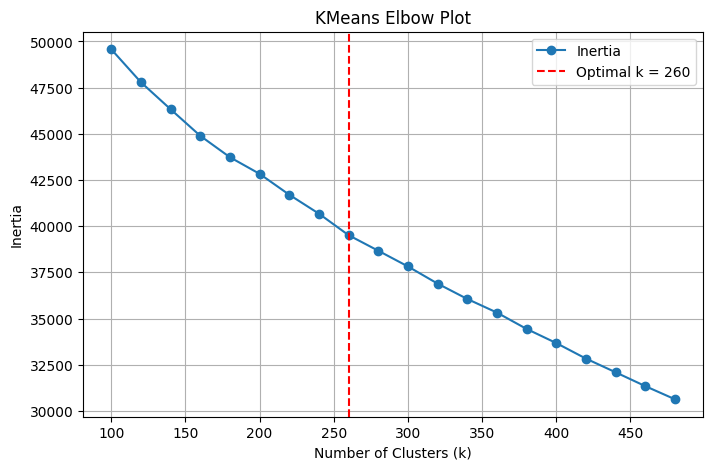

KMeans intermediate embeddings: (k=260


In [23]:
# kmeans
k_range = range(100, 500, 20)

# final embeddings
inertias = kmeans_elbow(final_embeddings, k_range)
final_optimal_k = plot_elbow_with_knee(k_range, inertias)
print(f"KMeans final embeddings: (k={final_optimal_k}")

# Intermediate embeddings
inertias = kmeans_elbow(intermediate_embeddings, k_range)
inter_optimal_k = plot_elbow_with_knee(k_range, inertias)
print(f"KMeans intermediate embeddings: (k={inter_optimal_k}")

In [24]:
# final
kmeans = KMeans(n_clusters=final_optimal_k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(final_embeddings)
score = evaluate_clustering(final_embeddings, labels)
print(f"KMeans (k={final_optimal_k}): Silhouette = {score:.3f}")

# intermediate
kmeans = KMeans(n_clusters=inter_optimal_k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(intermediate_embeddings)
score = evaluate_clustering(intermediate_embeddings, labels)
print(f"KMeans (k={inter_optimal_k}): Silhouette = {score:.3f}")

KMeans (k=260): Silhouette = 0.016
KMeans (k=260): Silhouette = 0.052


### 4-2. KMEANS TUNING ANALYSIS
- Final: 0.052 -> 0.016
- Intermediate: 0.050 -> 0.052

### 5. Next token prediction
- model: gpt

In [25]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from collections import defaultdict
import torch

# Load GPT-2
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

token_clusters = defaultdict(list)

for sent in sentences:
    # Tokenize and encode with GPT2
    inputs = tokenizer(sent, return_tensors="pt")
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits

    # Get last position's prediction (next token)
    next_token_logits = logits[0, -1]  # shape: [vocab_size]
    predicted_token_id = torch.argmax(next_token_logits).item()
    predicted_token = tokenizer.decode([predicted_token_id])

    # Group sentence by predicted token
    token_clusters[predicted_token].append(sent)

# Print Top Clusters
for token, cluster_sents in sorted(token_clusters.items(), key=lambda x: -len(x[1]))[:10]:
    print(f"\nToken: '{token}' — {len(cluster_sents)} sentences")
    for s in cluster_sents[:5]:  # Show up to 5 samples per token
        print("  -", s)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Token: '
' — 933 sentences
  - sadly , she could nt say that her first love was davis , mason s father .
  - aw , you love your godmother , do nt you noah ?
  - thank god he loves his baths ,  aidan muttered beside pesh .
  - i love aidan , but he s not necessarily a gentleman .
  - and with a wink , he walked off to join emma , leaving megan to wonder why everyone seemed so concerned with hers and pesh s love lives .

Token: ' .' — 543 sentences
  - he loved them too much to be denied .
  - it was nt until she fell in love for the first time in her life that she threw everything away .
  - as megan listened to him speak with such reverence and love about his late wife , she could nt help feeling just a little bit jealous .
  - she could nt imagine ever being loved so completely by a man that not even death could lessen his feelings .
  - all of us have the ability to love people in infinite capacities .

Token: '.' — 122 sentences
  - i could never , ever love another man like i do h

In [26]:
def get_gpt_embedding(sent):
    inputs = tokenizer(sent, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.transformer(**inputs)
        hidden_states = outputs.last_hidden_state  # shape: [1, seq_len, hidden_size]
        mean_embedding = hidden_states.mean(dim=1).squeeze(0)  # shape: [hidden_size]
    return mean_embedding.cpu().numpy()

In [27]:
all_embeddings = [get_gpt_embedding(sent) for sent in sentences]

label_map = {}
for i, (token, sents) in enumerate(token_clusters.items()):
    for s in sents:
        label_map[s] = i

labels = [label_map[s] for s in sentences]

score = silhouette_score(all_embeddings, labels, metric="cosine")
print(f"\nSilhouette Score for GPT2 next-token clustering: {score:.4f}")


Silhouette Score for GPT2 next-token clustering: -0.6761


### 5-2. GPT-BASED CLUSTERING ANALYSIS
score: -0.5086 -> -0.6761

### 6. LLMedge Refine Clustering

In [32]:
K = 260

# 1) Initial Clustering: K-means
kmeans = KMeans(n_clusters=K, random_state=42)
initial_labels = kmeans.fit_predict(final_embeddings)

# 2) Super-Point Enhanced Clustering
from sklearn.cluster import AgglomerativeClustering

def get_super_points(X, labels, alpha):
    super_points = []
    non_super_points = []

    for cluster_id in np.unique(labels):
        cluster_indices = np.where(labels == cluster_id)[0]
        cluster_vecs = X[cluster_indices]
        centroid = cluster_vecs.mean(axis=0)

        dists = np.linalg.norm(cluster_vecs - centroid, axis=1)
        cutoff = np.percentile(dists, 100 - alpha * 100)

        super_idx = cluster_indices[dists >= cutoff]
        rest_idx = cluster_indices[dists < cutoff]

        super_points.extend(super_idx)
        non_super_points.extend(rest_idx)

    return super_points, non_super_points

def recluster_with_super_points(X, super_points, non_super_points):
    from sklearn.metrics.pairwise import cosine_distances

    all_vecs = np.vstack([X[super_points], X[non_super_points]])
    clustering = AgglomerativeClustering(n_clusters=K, metric='cosine', linkage='average')
    return clustering.fit_predict(all_vecs)

In [33]:
alpha = 0.1  # super point

super_points, non_super_points = get_super_points(final_embeddings, initial_labels, alpha)

# (1) All super_point + non_super_point vector + (2) re-clustering via Agglomerative Clustering
spec_labels = recluster_with_super_points(final_embeddings, super_points, non_super_points)

In [34]:
print(spec_labels)

[125   0  17 ...   0   0   0]


## Linear Regeression plot based on best token

In [ ]:
def get_count(groups):
  group_counts = []
  word_counts = []

  for group in groups:
    group_counts.append(len(group))

    unique_words = set() # prevent duplicates
    for idx in group:
      unique_words.update(sentences[idx].split())
    word_counts.append(len(unique_words))
  return group_counts, word_counts # num of sentence per group, num of word per group

In [ ]:
print("--Graph Grouping--")
graph_group_counts_final, graph_word_counts_final = get_count(final_graph)
graph_group_counts_inter, graph_word_counts_inter = get_count(inter_graph)

print("Final layers' Group Counts of first 5th group:", graph_group_counts_final[:5])
print("Intermediate layers' Group Counts of first 5th group:", graph_group_counts_inter[:5])

--Graph Grouping--
Final layers' Group Counts of first 5th group: [986, 1, 1, 1, 1]
Intermediate layers' Group Counts of first 5th group: [993, 1, 2, 1, 1]


In [ ]:
def rearrange_decreasing_order(counts_vector):
  counts_vector = np.array(counts_vector)
  sorted_indices = np.argsort(-counts_vector)
  sorted_sent_counts = counts_vector[sorted_indices]
  return sorted_sent_counts

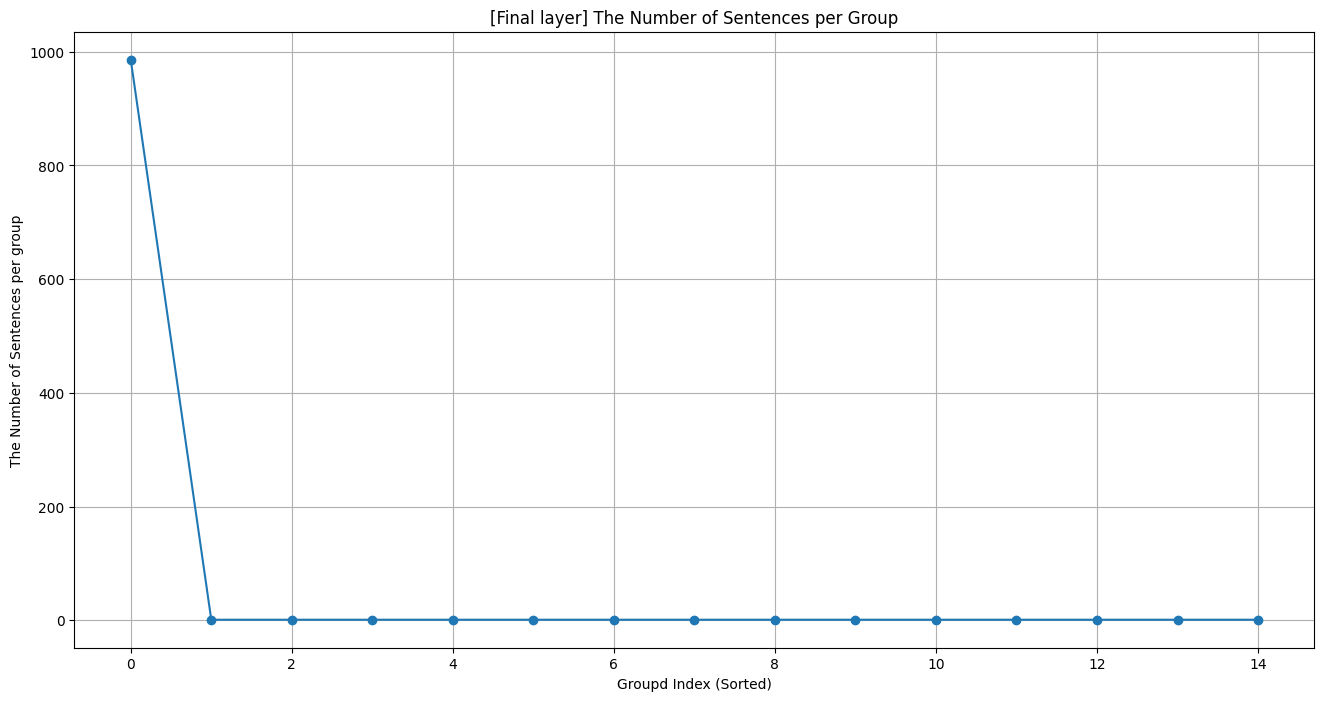

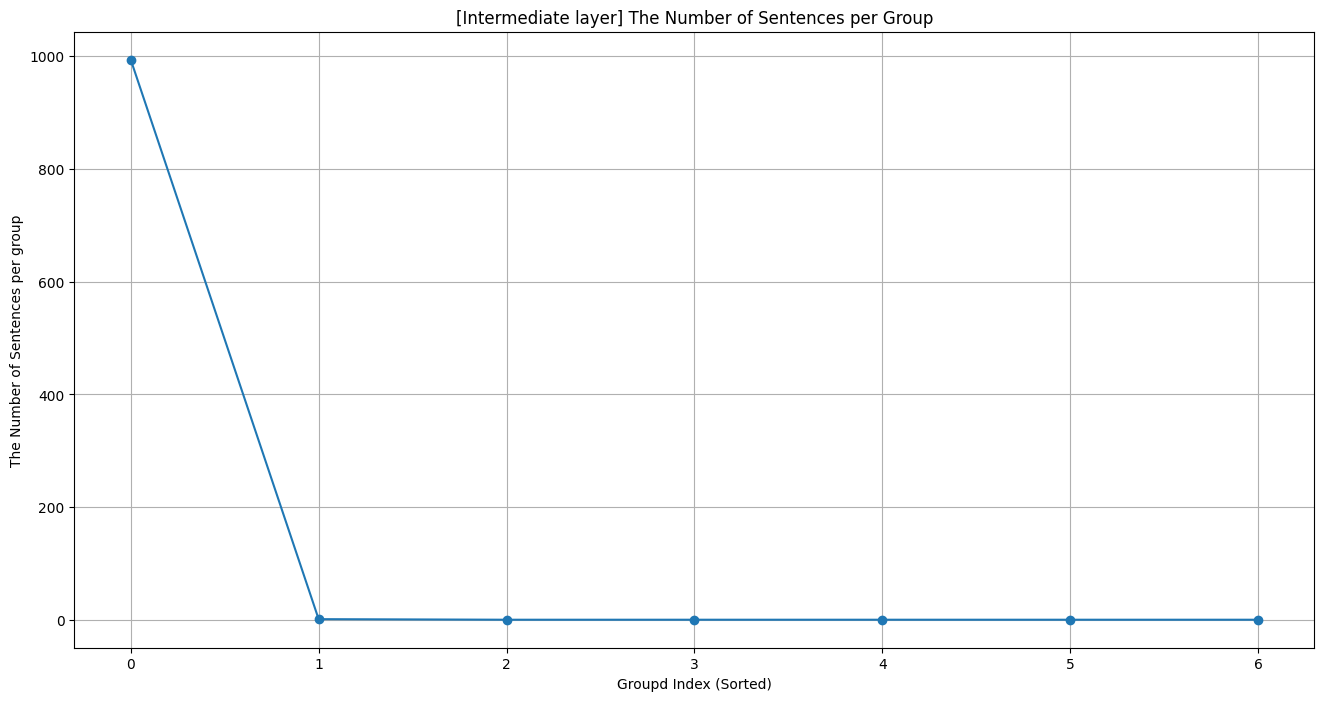

In [ ]:
# rearrange in decreaing order (ranking)
sorted_sent_counts_final = rearrange_decreasing_order(graph_group_counts_final)
sorted_sent_counts_inter = rearrange_decreasing_order(graph_group_counts_inter)

def plotting(flag, sorted_sent_counts):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"
  # x-axis
  plt.figure(figsize=(16,8))
  plt.plot(range(len(sorted_sent_counts)), sorted_sent_counts, marker='o', linestyle="-")


  plt.xlabel("Groupd Index (Sorted)")
  plt.ylabel("The Number of Sentences per group")
  plt.title(detail + " The Number of Sentences per Group")
  plt.grid(True)

  plt.show()

plotting(True, sorted_sent_counts_final)
plotting(False, sorted_sent_counts_inter)

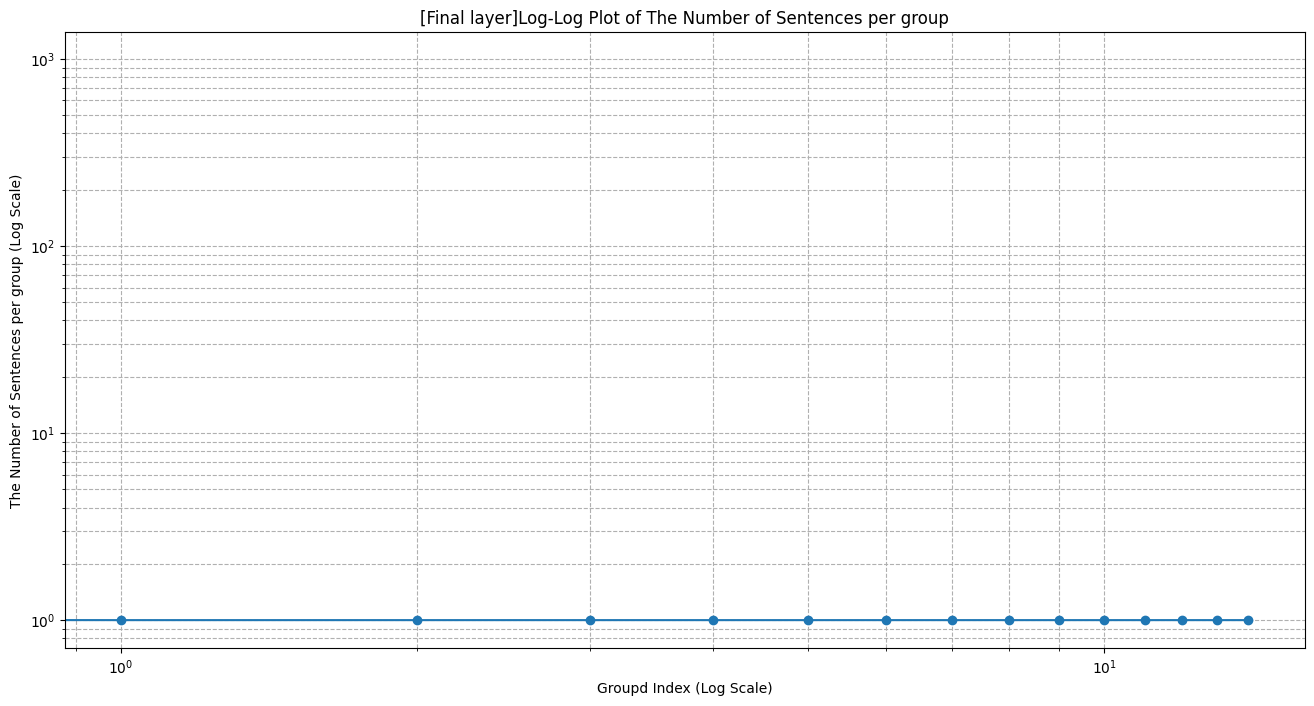

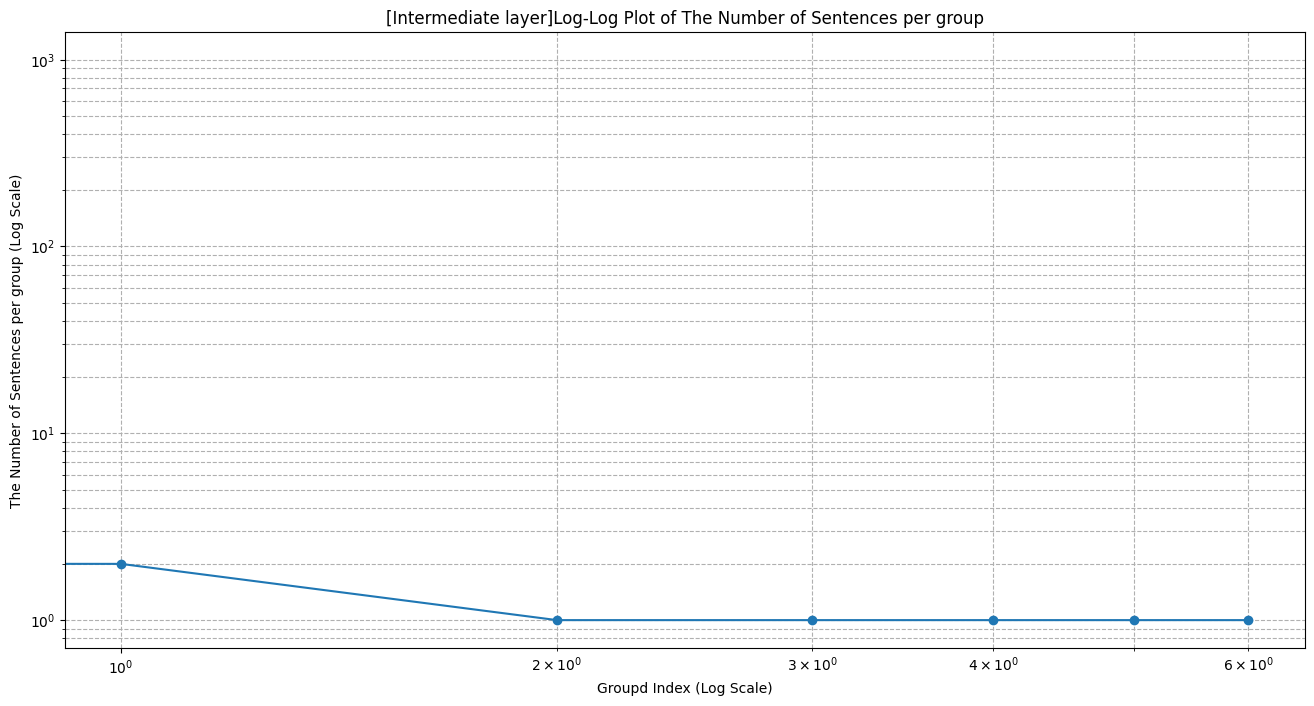

In [ ]:
# Also plot the log log plot using the count matrix.
def loglog_plotting(flag, sorted_sent_counts):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"
  plt.figure(figsize=(16,8))
  plt.loglog(range(len(sorted_sent_counts)), sorted_sent_counts, marker="o", linestyle="-")

  plt.xlabel("Groupd Index (Log Scale)")
  plt.ylabel("The Number of Sentences per group (Log Scale)")
  plt.title(detail + "Log-Log Plot of The Number of Sentences per group")
  plt.grid(True, which="both", linestyle="--")

  plt.show()

loglog_plotting(True, sorted_sent_counts_final)
loglog_plotting(False, sorted_sent_counts_inter)

In [ ]:
from scipy.stats import linregress

def linear_regression(sorted_sent_counts):
  x = np.log10(np.arange(1, len(sorted_sent_counts)+1))
  y = np.log10(sorted_sent_counts)

  # linear regression
  slope, intercept, r_val, p_val, std_err = linregress(x, y)

  # regression prediction
  y_pred = slope * x + intercept

  return x, y, slope, intercept, r_val, p_val, y_pred

In [ ]:
def return_linear_regression_result(flag, sorted_sent_counts):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"

  x, y, slope, intercept, r_val, p_val, y_pred = linear_regression(sorted_sent_counts)

  print(detail + "Linear Regression Prediction: y = slope * x + intercept")
  print(f"y ={slope:.2f}x + {intercept:.2f}")

  print(f"Linear Regression Results:")
  print(f"   - Slope: {slope:.4f}")
  print(f"   - Intercept: {intercept:.4f}")
  print(f"   - R-squared: {r_val**2:.4f}")
  print(f"   - P-value: {p_val:.4e}")

In [ ]:
# rearrange in decreaing order (ranking)
linear_regression(sorted_sent_counts_final)
linear_regression(sorted_sent_counts_inter)

(array([0.        , 0.30103   , 0.47712125, 0.60205999, 0.69897   ,
        0.77815125, 0.84509804]),
 array([2.99694925, 0.30103   , 0.        , 0.        , 0.        ,
        0.        , 0.        ]),
 np.float64(-3.116011173171814),
 np.float64(2.1192563090880188),
 np.float64(-0.8278803711168231),
 np.float64(0.021466593713501562),
 array([ 2.11925631,  1.18124348,  0.63254115,  0.24323065, -0.05874203,
        -0.30547168, -0.51407863]))

In [ ]:
def linear_regression_plotting(flag, sorted_sent_counts, model):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"

  x, y, slope, intercept, r_val, p_val, y_pred = linear_regression(sorted_sent_counts)

  plt.figure(figsize=(16,8))
  plt.scatter(x, y, label="Sentences counts (Log-Log)", alpha=0.8, marker="o")
  plt.plot(x, y_pred, color = "red", label=f"Linear Fit: y={slope:.2f}x + {intercept:.2f}")
  plt.text(0.1, 1.2, f"$R^2$ = {r_val**2:.4f}", fontsize=14, color="black")

  plt.xlabel("Group Index (Log scale)")
  plt.ylabel("The Number of Sentences per group (Log scale)")
  plt.title(detail + "Linear Regression on Log-Log Scale - " + model)
  plt.legend()
  plt.grid(True)

  plt.show()

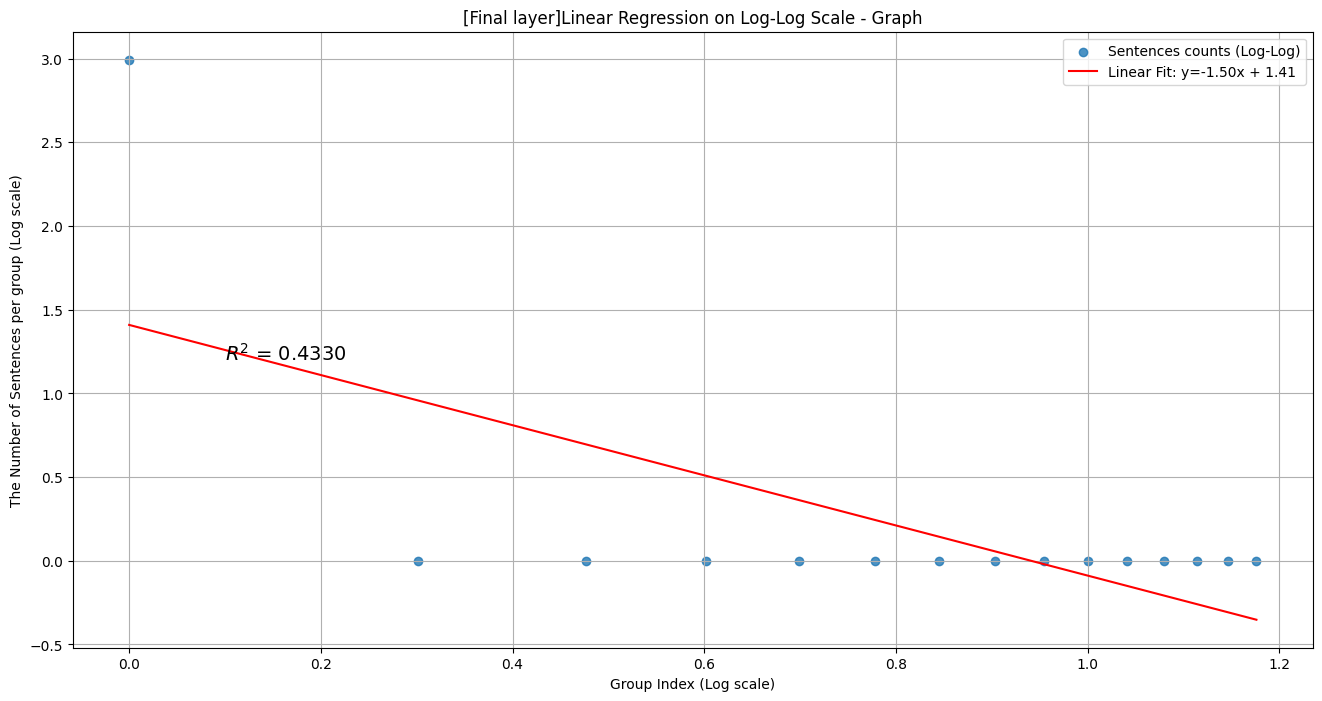

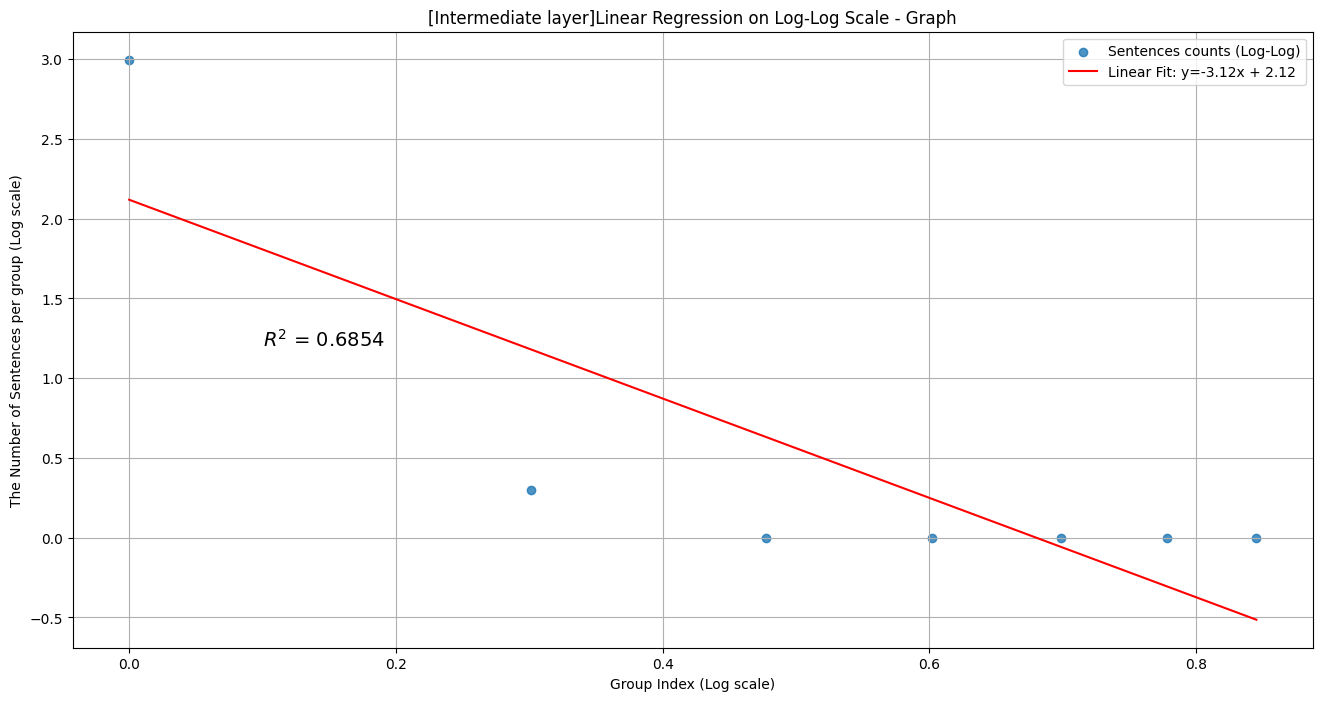

In [ ]:
linear_regression_plotting(True, sorted_sent_counts_final, "Graph")
linear_regression_plotting(False, sorted_sent_counts_inter, "Graph")

## best model: intermediate graph

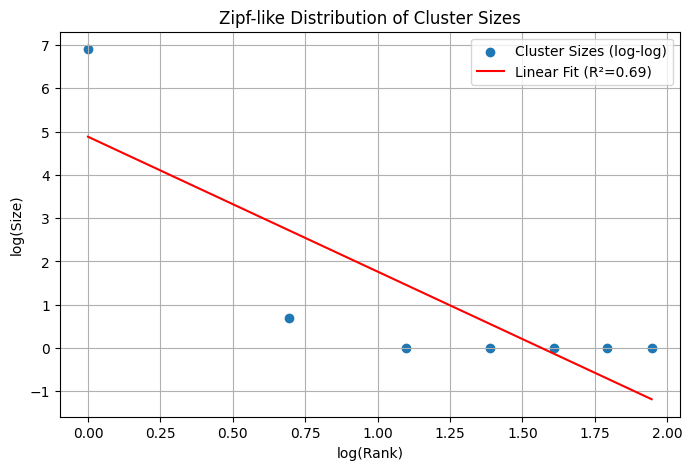

Linear Regression Slope: -3.1160
Intercept: 4.8798
R² Score: 0.6854


In [ ]:
from sklearn.linear_model import LinearRegression

# Step 1: Count sentences per cluster
cluster_sizes = [len(cluster) for cluster in inter_graph]  # or final_graph
cluster_sizes.sort(reverse=True)

# Step 2: Prepare data for regression
ranks = np.arange(1, len(cluster_sizes) + 1)
sizes = np.array(cluster_sizes)

# Optionally log-log for Zipf analysis
log_ranks = np.log(ranks).reshape(-1, 1)
log_sizes = np.log(sizes)

# Step 3: Fit linear regression
model = LinearRegression()
model.fit(log_ranks, log_sizes)
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(log_ranks, log_sizes)

# Step 4: Plot
plt.figure(figsize=(8, 5))
plt.scatter(log_ranks, log_sizes, label="Cluster Sizes (log-log)")
plt.plot(log_ranks, model.predict(log_ranks), color="red", label=f"Linear Fit (R²={r2:.2f})")
plt.xlabel("log(Rank)")
plt.ylabel("log(Size)")
plt.title("Zipf-like Distribution of Cluster Sizes")
plt.legend()
plt.grid(True)
plt.show()

# Optional: print regression stats
print(f"Linear Regression Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R² Score: {r2:.4f}")
